# Hello world

In [17]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Train/val split

In [18]:
Data_DIR = "../data/images/"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 1337

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    Data_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",

)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    Data_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",

)

class_names = train_ds_raw.class_names
num_classes = len(class_names)


train_ds = train_ds_raw
val_ds = val_ds_raw


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)


Found 20580 files belonging to 120 classes.
Using 16464 files for training.
Found 20580 files belonging to 120 classes.
Using 4116 files for validation.


In [19]:
print(IMG_SIZE + (3,), BATCH_SIZE, SEED)

(224, 224, 3) 32 1337


## Baseline and compile

In [20]:
base = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,)
)
base.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = tf.keras.applications.efficientnet.preprocess_input(inputs)
x = base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="top1"),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5"),
    ],
)

## Fit the base-model

In [21]:
history_clean = model.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 124s 223ms/step - loss: 1.3197 - top1: 0.7213 - top5: 0.9209 - val_loss: 0.5741 - val_top1: 0.8433 - val_top5: 0.9854
Epoch 2/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 114s 221ms/step - loss: 0.4910 - top1: 0.8642 - top5: 0.9888 - val_loss: 0.4867 - val_top1: 0.8554 - val_top5: 0.9864
Epoch 3/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 115s 223ms/step - loss: 0.3804 - top1: 0.8897 - top5: 0.9934 - val_loss: 0.4518 - val_top1: 0.8625 - val_top5: 0.9864
Epoch 4/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 118s 228ms/step - loss: 0.3135 - top1: 0.9096 - top5: 0.9954 - val_loss: 0.4481 - val_top1: 0.8550 - val_top5: 0.9886
Epoch 5/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 117s 228ms/step - loss: 0.2646 - top1: 0.9241 - top5: 0.9977 - val_loss: 0.4381 - val_top1: 0.8550 - val_top5: 0.9876


## Corrupt

### Random noice

In [22]:
def add_noise(img, label, std=255.0,mean=-50.0):
    noise = tf.random.normal(tf.shape(img), mean=mean, stddev=std)
    img = tf.clip_by_value(img + noise, 0.0, 255.0)
    return img, label

val_ds_noise = (val_ds_raw
                .map(lambda img, label: add_noise(img, label, std=40.0)))

### Jpeg compression

In [23]:
def jpeg_compression(img, label, quality=1):
    img = tf.cast(img, tf.uint8)                 
    x = tf.io.encode_jpeg(img, quality=quality)
    img = tf.io.decode_jpeg(x, channels=3)
    img = tf.cast(img, tf.float32)
    return img, label


val_ds_jpeg = (val_ds_raw
               .unbatch()
               .map(lambda x, y: jpeg_compression(x, y),)
               .batch(BATCH_SIZE))

### Blur

In [24]:
def blur(img, label, k=5):
    img4 = tf.expand_dims(img, 0) 
    img4 = tf.nn.avg_pool2d(img4, ksize=k, strides=1, padding="SAME")
    img = tf.squeeze(img4, 0)      
    return img, label

val_ds_blur = (val_ds_raw
               .unbatch()
               .map(lambda x, y: blur(x, y),)
               .batch(BATCH_SIZE))


## Print

In [26]:
for images, labels in val_ds_raw.take(1):
    original = images[0]
    break

In [27]:
noisy, _ = add_noise(original, None, std=40.0)
jpeg, _ = jpeg_compression(original, None)
blurred, _ = blur(original, None)

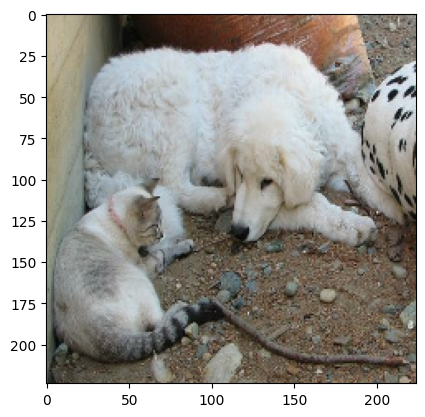

In [28]:
plt.imshow(original.numpy().astype("uint8"))

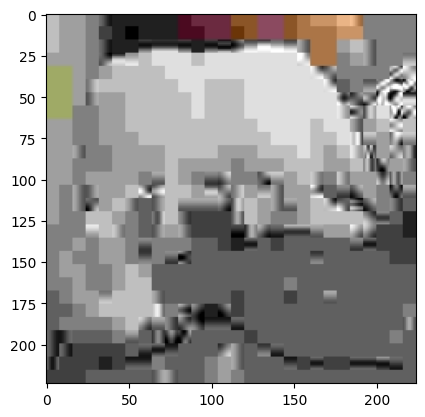

In [29]:
plt.imshow(jpeg.numpy().astype("uint8"))

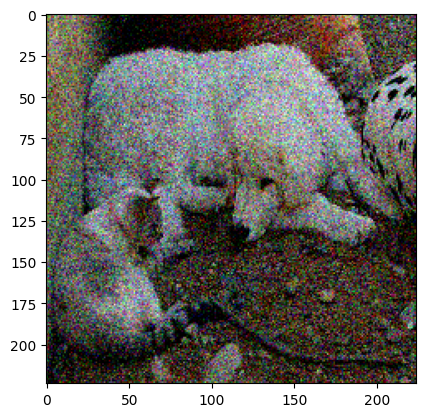

In [30]:
plt.imshow(noisy.numpy().astype("uint8"))

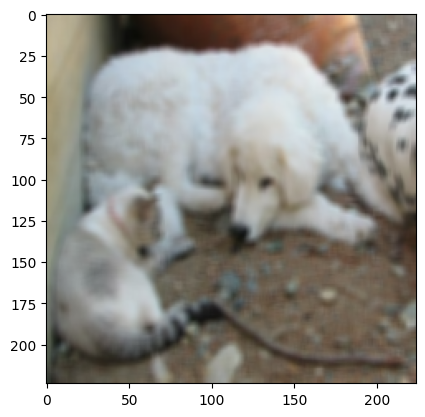

In [31]:
plt.imshow(blurred.numpy().astype("uint8"))

## Corrupt some input data

In [32]:
def corrupt_fraction(train_ds_raw, corrupt_fn, p=0.5, seed=1337, batch_size=32, shuffle=True):

    ds = train_ds_raw.unbatch().enumerate() # Add an index to each element

    def maybe_corrupt(i, data): 
        img, label = data 

        # Create a random number in [0, 1) using a stateless random generator
        r = tf.random.stateless_uniform(
            shape=[], 
            seed=tf.stack([tf.cast(seed, tf.int32), tf.cast(i, tf.int32)]), # Use the index as part of the seed to ensure different random numbers for each element
            
        )
    
        return tf.cond(
            r < p,
            lambda: corrupt_fn(img, label), # true case: apply corruption
            lambda: (img, label) # false case: return original
        )

    ds = ds.map(maybe_corrupt)
    if shuffle:
        ds = ds.shuffle(2000, seed=seed, reshuffle_each_iteration=True)

    ds = ds.batch(batch_size)
    return ds

# Ny

#
1. for looop mmed ex jpeg 1% 5% 15% på training data sen evaluate
2. vad den gissar fel/rätt på
3. leder corrupt trändata till ökad prestetaion på rätt korrupt data
4. tensorflowboard
5. vad den gissar för classer

In [43]:
class_names = train_ds_raw.class_names
num_classes = len(class_names)

def build_model():
    base = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=IMG_SIZE + (3,)
    )
    base.trainable = False

    inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = tf.keras.applications.efficientnet.preprocess_input(inputs)
    x = base(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=[
            tf.keras.metrics.SparseCategoricalAccuracy(name="top1"),
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5"),
        ],
    )
    return model

In [44]:
corruption_levels = [0.05]

corruptions = {
    "blur": lambda img, label: blur(img, label, k=5),
    "noise": lambda img, label: add_noise(img, label, std=40.0),
    "jpeg": lambda img, label: jpeg_compression(img, label, quality=30),
}

In [45]:
results = []


for corruption_name, corruption_fn in corruptions.items():
    for p in corruption_levels:
        print(f"Training with {(p*100)}% corrupted images with {corruption_name}...")

        if p == 0.0:
            train_variant = train_ds_raw
        else:
            train_variant = corrupt_fraction(
                train_ds_raw,
                corrupt_fn=corruption_fn,
                p=p,
                seed=SEED,
                batch_size=BATCH_SIZE,
            )

        model = build_model()

        history = model.fit(
            train_variant,
            validation_data=val_ds,
            epochs=2,
        )

        val_loss, val_top1, val_top5 = model.evaluate(val_ds, verbose=0)

        results.append({
            "corruption_type": corruption_name,
            "p": p,
            "val_loss": val_loss,
            "val_top1": val_top1,
            "val_top5": val_top5
        })

Training with 5.0% corrupted images with blur...
Epoch 1/2
    515/Unknown 99s 185ms/step - loss: 2.2889 - top1: 0.5426 - top5: 0.7753

c:\Users\Emil\Desktop\skola\BDP\BDP\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


515/515 ━━━━━━━━━━━━━━━━━━━━ 124s 232ms/step - loss: 1.3502 - top1: 0.7077 - top5: 0.9152 - val_loss: 0.5804 - val_top1: 0.8406 - val_top5: 0.9864
Epoch 2/2
515/515 ━━━━━━━━━━━━━━━━━━━━ 118s 229ms/step - loss: 0.5236 - top1: 0.8529 - top5: 0.9861 - val_loss: 0.4784 - val_top1: 0.8603 - val_top5: 0.9871
Training with 5.0% corrupted images with noise...
Epoch 1/2
515/515 ━━━━━━━━━━━━━━━━━━━━ 128s 240ms/step - loss: 1.3759 - top1: 0.7040 - top5: 0.9121 - val_loss: 0.5812 - val_top1: 0.8401 - val_top5: 0.9849
Epoch 2/2
515/515 ━━━━━━━━━━━━━━━━━━━━ 121s 234ms/step - loss: 0.5612 - top1: 0.8461 - top5: 0.9815 - val_loss: 0.4797 - val_top1: 0.8550 - val_top5: 0.9871
Training with 5.0% corrupted images with jpeg...
Epoch 1/2
515/515 ━━━━━━━━━━━━━━━━━━━━ 128s 241ms/step - loss: 1.3251 - top1: 0.7165 - top5: 0.9187 - val_loss: 0.5825 - val_top1: 0.8379 - val_top5: 0.9852
Epoch 2/2
515/515 ━━━━━━━━━━━━━━━━━━━━ 122s 236ms/step - loss: 0.5061 - top1: 0.8592 - top5: 0.9880 - val_loss: 0.4747 - val_t